# Algorithmic Trading Project

This notebook downloads 1-hour OHLCV data from Binance for `BTCUSDT`, `ETHUSDT`, and an optional altcoin (`DOGEUSDT` by default), stores the raw market data in Parquet, audits data quality, constructs excess simple returns using the previous-step risk-free rate, flags return outliers with a rolling z-score filter, and displays the flagged rows without altering the original candles.

In [126]:
import os
import sys
import time
from datetime import datetime, timezone
from pathlib import Path
from fredapi import Fred
import ccxt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from dotenv import load_dotenv



def _project_root() -> Path:
    here = Path.cwd().resolve()
    if (here / "strategy_helpers.py").exists():
        return here
    for parent in here.parents:
        if (parent / "strategy_helpers.py").exists():
            return parent
    return here


_root = _project_root()
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from strategy_helpers import (
    build_cross_sectional_inputs,
    build_diagnostics_tail_table,
    build_parameter_table,
    build_results_summary_table,
    build_strategy_comparison_table,
    estimate_roll_spread_rolling,
    load_hourly_risk_free_rate,
    run_cost_sensitivity_analysis,
    run_cross_sectional_parameter_sweep,
    run_cross_sectional_strategy,
    run_data_quality_pipeline,
    run_mean_reversion_walk_forward,
    run_pair_diagnostics,
    run_roll_model,
    run_tsmom_parameter_sweep,
    run_tsmom_strategy,
    run_tsmom_walk_forward,
    summarize_strategy_state,
    write_parquet_safe,
)

load_dotenv()

True

In [127]:
SYMBOLS    = ["BTC/USDT", "ETH/USDT", "DOGE/USDT", "SOL/USDT"]
TIMEFRAME  = "1d"
SINCE      = "2020-01-01"
UNTIL      = "2026-03-23"
DATA_DIR   = Path("data")

In [128]:
exchange = ccxt.binance()
since_ms = exchange.parse8601(f"{SINCE}T00:00:00Z")
until_ms = exchange.parse8601(f"{UNTIL}T23:59:59Z")

for symbol in SYMBOLS:
    print(f"Downloading {symbol}...", end="", flush=True)

    all_bars = []
    since = since_ms

    while True:
        bars = exchange.fetch_ohlcv(symbol, timeframe=TIMEFRAME, since=since, limit=1000)
        if not bars:
            break

        # Keep only bars in the requested [SINCE, UNTIL] range.
        bars = [bar for bar in bars if bar[0] <= until_ms]
        if not bars:
            break

        all_bars.extend(bars)
        since = bars[-1][0] + 1
        print(".", end="", flush=True)
        time.sleep(0.3)

        if bars[-1][0] >= until_ms:
            break

    df = pd.DataFrame(
        all_bars,
        columns=["timestamp", "open", "high", "low", "close", "volume"],
    )
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.set_index("timestamp").sort_index()

    fname = DATA_DIR / f"{symbol.replace('/', '')}_{TIMEFRAME}.parquet"
    write_parquet_safe(df, fname)
    print(f" {len(df):,} bars -> {fname}")

print("Done.")


Done.


### Macro Data — Effective Fed Funds Rate (FRED)

In [129]:
fred = Fred(api_key=os.environ["FRED_API_KEY"])

dff = fred.get_series("DFF", observation_start=SINCE, observation_end=UNTIL)
dff = dff.rename("fed_funds_rate").rename_axis("date")
dff.index = pd.to_datetime(dff.index, utc=True)

dff_path = DATA_DIR / "DFF_daily.parquet"
dff.to_frame().to_parquet(dff_path, engine="pyarrow")
print(f"Fed Funds Rate: {len(dff):,} observations → {dff_path}")
dff.tail()

Fed Funds Rate: 2,271 observations → data/DFF_daily.parquet


date
2026-03-16 00:00:00+00:00    3.64
2026-03-17 00:00:00+00:00    3.64
2026-03-18 00:00:00+00:00    3.64
2026-03-19 00:00:00+00:00    3.64
2026-03-20 00:00:00+00:00    3.64
Name: fed_funds_rate, dtype: float64

### Data Cleaning

In [130]:
PROCESSED_DIR = DATA_DIR / "processed" / "binance"
RF_PATH = DATA_DIR / "DFF_daily.parquet"
HOURS_PER_YEAR = 24 * 365

risk_free_rate = load_hourly_risk_free_rate(RF_PATH, hours_per_year=HOURS_PER_YEAR)
quality_state = run_data_quality_pipeline(
    data_dir=DATA_DIR,
    processed_dir=PROCESSED_DIR,
    symbols=SYMBOLS,
    timeframe=TIMEFRAME,
    risk_free_rate=risk_free_rate,
)

flagged_frames = quality_state["flagged_frames"]
quality_report = quality_state["quality_report"]
post_clean_checks = quality_state["post_clean_checks"]
flagged_outliers = quality_state["flagged_outliers"]
outlier_counts = quality_state["outlier_counts"]

display(quality_report)
display(post_clean_checks)
display(outlier_counts)
display(flagged_outliers.head(10))


,symbol,stage,rows,start,end,duplicate_timestamps,missing_bars,null_rows,null_values,non_positive_price_rows,negative_volume_rows,zero_volume_rows,high_below_low_rows,candle_rule_violations,max_gap_hours,outliers_flagged,missing_bar_rows
0,BTC/USDT,flagged,2274,2020-01-01 00:00:00+00:00,2026-03-23 00:00:00+00:00,0,0,0,0,0,0,0,0,0,24.0,2,0
1,BTC/USDT,raw,2274,2020-01-01 00:00:00+00:00,2026-03-23 00:00:00+00:00,0,0,0,0,0,0,0,0,0,24.0,0,0
2,DOGE/USDT,flagged,2274,2020-01-01 00:00:00+00:00,2026-03-23 00:00:00+00:00,0,0,0,0,0,0,0,0,0,24.0,8,0
3,DOGE/USDT,raw,2274,2020-01-01 00:00:00+00:00,2026-03-23 00:00:00+00:00,0,0,0,0,0,0,0,0,0,24.0,0,0
4,ETH/USDT,flagged,2274,2020-01-01 00:00:00+00:00,2026-03-23 00:00:00+00:00,0,0,0,0,0,0,0,0,0,24.0,2,0
5,ETH/USDT,raw,2274,2020-01-01 00:00:00+00:00,2026-03-23 00:00:00+00:00,0,0,0,0,0,0,0,0,0,24.0,0,0
6,SOL/USDT,flagged,2051,2020-08-11 00:00:00+00:00,2026-03-23 00:00:00+00:00,0,0,0,0,0,0,0,0,0,24.0,1,0
7,SOL/USDT,raw,2051,2020-08-11 00:00:00+00:00,2026-03-23 00:00:00+00:00,0,0,0,0,0,0,0,0,0,24.0,0,0


,symbol,missing_bars,null_rows,non_positive_price_rows,negative_volume_rows,high_below_low_rows,candle_rule_violations,outliers_flagged
0,BTC/USDT,0,0,0,0,0,0,2
2,DOGE/USDT,0,0,0,0,0,0,8
4,ETH/USDT,0,0,0,0,0,0,2
6,SOL/USDT,0,0,0,0,0,0,1


,symbol,flagged_outlier_count
0,BTC/USDT,2
1,DOGE/USDT,8
2,ETH/USDT,2
3,SOL/USDT,1


,timestamp,symbol,open,high,low,close,volume,simple_return,risk_free_rate,excess_simple_return,return_zscore
0,2020-03-12 00:00:00+00:00,BTC/USDT,7934.580000,7966.170000,4410.000000,4800.000000,2.615056e+05,-0.395048,1.237560e-06,-0.395050,-7.048397
1,2026-02-05 00:00:00+00:00,BTC/USDT,73165.840000,73341.180000,62345.000000,62909.860000,1.062988e+05,-0.140174,4.081420e-06,-0.140178,-5.147420
4,2020-03-12 00:00:00+00:00,DOGE/USDT,0.002176,0.002181,0.001400,0.001600,7.708100e+08,-0.263400,1.237560e-06,-0.263401,-5.318093
5,2020-07-07 00:00:00+00:00,DOGE/USDT,0.002619,0.003295,0.002600,0.003136,3.965389e+09,0.197266,1.026935e-07,0.197266,5.458930
6,2020-07-08 00:00:00+00:00,DOGE/USDT,0.003136,0.005600,0.002910,0.004766,2.365701e+10,0.519675,1.026935e-07,0.519675,7.277339
7,2020-11-21 00:00:00+00:00,DOGE/USDT,0.002987,0.003606,0.002980,0.003513,3.288496e+09,0.176163,9.128769e-08,0.176163,6.448246
8,2021-01-02 00:00:00+00:00,DOGE/USDT,0.005678,0.013988,0.005524,0.010526,4.633335e+10,0.853239,1.026935e-07,0.853239,7.070953
9,2021-01-28 00:00:00+00:00,DOGE/USDT,0.007410,0.037485,0.007288,0.036499,1.029898e+11,3.924114,9.128769e-08,3.924114,8.142648
10,2021-04-16 00:00:00+00:00,DOGE/USDT,0.182500,0.450000,0.179100,0.365443,5.751055e+10,1.003968,7.988072e-08,1.003968,5.755455
11,2022-10-29 00:00:00+00:00,DOGE/USDT,0.083870,0.151500,0.082850,0.121760,1.530881e+10,0.451771,3.462928e-06,0.451767,6.842103


### Excess Return Time Series

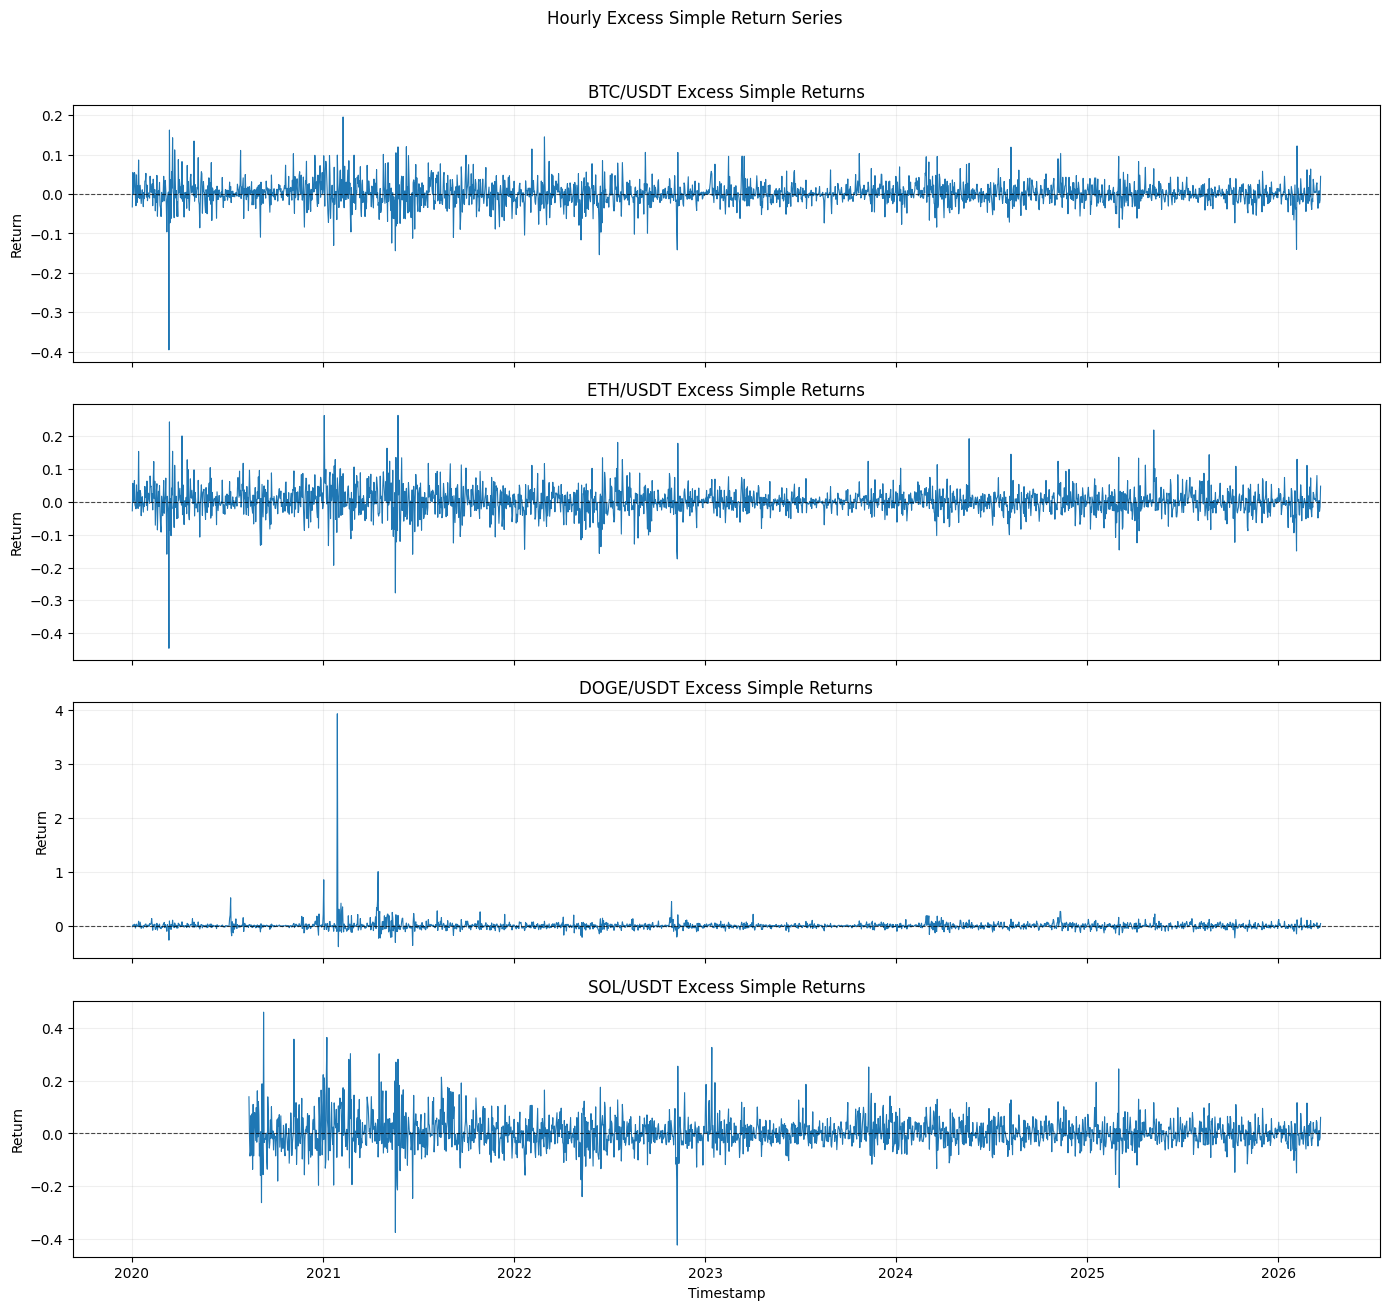

In [131]:
fig, axes = plt.subplots(len(SYMBOLS), 1, figsize=(14, 3.2 * len(SYMBOLS)), sharex=True)

if len(SYMBOLS) == 1:
    axes = [axes]

for ax, symbol in zip(axes, SYMBOLS):
    plot_frame = flagged_frames[symbol]
    ax.plot(plot_frame.index, plot_frame["excess_simple_return"], lw=0.8, color="tab:blue")
    ax.axhline(0.0, color="black", lw=0.8, ls="--", alpha=0.7)
    ax.set_title(f"{symbol} Excess Simple Returns")
    ax.set_ylabel("Return")
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Timestamp")
fig.suptitle("Hourly Excess Simple Return Series", y=1.02)
fig.tight_layout()
plt.show()


## Strategy 1: Cross-Sectional Mean Reversion

We align all four assets on a common hourly index and use the cleaned excess-return series already stored in `flagged_frames`. Rather than ranking raw returns, we estimate each asset's rolling beta to an equal-weight crypto basket and trade the short-horizon residual returns so the signal focuses on relative-value dislocations instead of broad market direction.


In [132]:
ASSET_COLUMNS = SYMBOLS
SIGNAL_RETURN_COLUMN = "clean_return"
PNL_RETURN_COLUMN = "clean_return"
BETA_WINDOW = 24 * 7
SIGNAL_LOOKBACK = 6
DISPERSION_LOOKBACK = 24 * 7

cross_sectional_inputs = build_cross_sectional_inputs(
    flagged_frames,
    ASSET_COLUMNS,
    signal_return_column=SIGNAL_RETURN_COLUMN,
    pnl_return_column=PNL_RETURN_COLUMN,
    beta_window=BETA_WINDOW,
    signal_lookback=SIGNAL_LOOKBACK,
    dispersion_lookback=DISPERSION_LOOKBACK,
)

close_df = cross_sectional_inputs["close_df"]
signal_return_df = cross_sectional_inputs["signal_return_df"]
pnl_return_df = cross_sectional_inputs["pnl_return_df"]
market_return_series = cross_sectional_inputs["market_return_series"]
beta_df = cross_sectional_inputs["beta_df"]
residual_return_df = cross_sectional_inputs["residual_return_df"]
residual_signal_df = cross_sectional_inputs["residual_signal_df"]
zscore_df = cross_sectional_inputs["zscore_df"]
cross_sectional_dispersion_series = cross_sectional_inputs["cross_sectional_dispersion_series"]
dispersion_floor_series = cross_sectional_inputs["dispersion_floor_series"]

display(close_df.tail())
display(zscore_df.tail())


,BTC/USDT,ETH/USDT,DOGE/USDT,SOL/USDT
timestamp,,,,
2026-03-19 00:00:00+00:00,69930.00,2137.81,0.09354,88.89
2026-03-20 00:00:00+00:00,70510.73,2146.22,0.09416,89.84
2026-03-21 00:00:00+00:00,68918.12,2084.87,0.09135,87.56
2026-03-22 00:00:00+00:00,67859.00,2053.89,0.09015,86.20
2026-03-23 00:00:00+00:00,70906.45,2152.03,0.09415,91.43


,BTC/USDT,ETH/USDT,DOGE/USDT,SOL/USDT
timestamp,,,,
2026-03-19 00:00:00+00:00,-0.680895,1.360193,-1.192741,0.513443
2026-03-20 00:00:00+00:00,-0.675495,1.137915,-1.266087,0.803667
2026-03-21 00:00:00+00:00,-1.569826,1.163495,-0.019741,0.426071
2026-03-22 00:00:00+00:00,-1.072539,-0.829412,0.530839,1.371111
2026-03-23 00:00:00+00:00,-0.330054,-1.241884,0.039882,1.532056


Signals are updated only on scheduled rebalance bars. We lag the residual z-scores by one bar, require cross-sectional dispersion to be above its own lagged rolling median, trade only the strongest loser against the strongest winner, and add hysteresis with separate entry and exit thresholds plus a minimum holding period so the book cannot flip every hour.


In [133]:
ENTRY_ZSCORE = 1.25
EXIT_ZSCORE = 0.5
REBALANCE_EVERY_BARS = 48
MIN_HOLD_BARS = 6
TOP_K = 1
MR_WEIGHTING_MODE = "inverse_vol"
MR_USE_REGIME_FILTER = True
MR_REGIME_TREND_LOOKBACK_BARS = 24
MR_REGIME_TREND_VOL_WINDOW = 24
MR_REGIME_TREND_ZSCORE_CAP = 1.0

mean_reversion_params = build_parameter_table(
    {
        "signal_return_column": SIGNAL_RETURN_COLUMN,
        "pnl_return_column": PNL_RETURN_COLUMN,
        "beta_window_bars": BETA_WINDOW,
        "signal_lookback_bars": SIGNAL_LOOKBACK,
        "dispersion_lookback_bars": DISPERSION_LOOKBACK,
        "entry_zscore": ENTRY_ZSCORE,
        "exit_zscore": EXIT_ZSCORE,
        "rebalance_every_bars": REBALANCE_EVERY_BARS,
        "min_hold_bars": MIN_HOLD_BARS,
        "top_k": TOP_K,
        "weighting_mode": MR_WEIGHTING_MODE,
        "use_regime_filter": MR_USE_REGIME_FILTER,
        "regime_trend_lookback_bars": MR_REGIME_TREND_LOOKBACK_BARS,
        "regime_trend_vol_window": MR_REGIME_TREND_VOL_WINDOW,
        "regime_trend_zscore_cap": MR_REGIME_TREND_ZSCORE_CAP,
    }
)

display(mean_reversion_params)


,value
signal_return_column,clean_return
pnl_return_column,clean_return
beta_window_bars,168
signal_lookback_bars,6
dispersion_lookback_bars,168
entry_zscore,1.25
exit_zscore,0.5
rebalance_every_bars,48
min_hold_bars,6
top_k,1


The upgraded mean-reversion book now uses a regime filter to avoid opening new trades when the equal-weight crypto market is already in a strong short-horizon trend. The idea is simple: cross-sectional mean-reversion works best when dispersion is present but the whole market is not moving one-way too aggressively. We therefore keep the slower `48`-bar rebalance, use inverse-vol sizing, allow moderate leverage up to `6x`, and only permit new entries when the lagged market-trend strength stays below a cap.


In [134]:
VOL_WINDOW = 72
INITIAL_CAPITAL_USDT = 10_000.0
GROSS_EXPOSURE_CAP_USDT = 100_000.0
MAX_GROSS_LEVERAGE = 6.0
TRANSACTION_COST_BPS = 10.0
MAX_TURNOVER_FRACTION = 0.50
LIQUIDATION_EQUITY_FLOOR_USDT = 2_500.0

execution_params = build_parameter_table(
    {
        "vol_window_bars": VOL_WINDOW,
        "initial_capital_usdt": INITIAL_CAPITAL_USDT,
        "gross_exposure_cap_usdt": GROSS_EXPOSURE_CAP_USDT,
        "max_gross_leverage": MAX_GROSS_LEVERAGE,
        "weighting_mode": MR_WEIGHTING_MODE,
        "use_regime_filter": MR_USE_REGIME_FILTER,
        "regime_trend_lookback_bars": MR_REGIME_TREND_LOOKBACK_BARS,
        "regime_trend_vol_window": MR_REGIME_TREND_VOL_WINDOW,
        "regime_trend_zscore_cap": MR_REGIME_TREND_ZSCORE_CAP,
        "transaction_cost_bps": TRANSACTION_COST_BPS,
        "max_turnover_fraction": MAX_TURNOVER_FRACTION,
        "liquidation_equity_floor_usdt": LIQUIDATION_EQUITY_FLOOR_USDT,
    }
)

strategy_state = run_cross_sectional_strategy(
    close_df=close_df,
    signal_return_df=signal_return_df,
    pnl_return_df=pnl_return_df,
    zscore_df=zscore_df,
    cross_sectional_dispersion_series=cross_sectional_dispersion_series,
    dispersion_floor_series=dispersion_floor_series,
    market_return_series=market_return_series,
    entry_zscore=ENTRY_ZSCORE,
    exit_zscore=EXIT_ZSCORE,
    rebalance_every_bars=REBALANCE_EVERY_BARS,
    min_hold_bars=MIN_HOLD_BARS,
    top_k=TOP_K,
    vol_window=VOL_WINDOW,
    use_regime_filter=MR_USE_REGIME_FILTER,
    regime_trend_lookback_bars=MR_REGIME_TREND_LOOKBACK_BARS,
    regime_trend_vol_window=MR_REGIME_TREND_VOL_WINDOW,
    regime_trend_zscore_cap=MR_REGIME_TREND_ZSCORE_CAP,
    weighting_mode=MR_WEIGHTING_MODE,
    initial_capital_usdt=INITIAL_CAPITAL_USDT,
    gross_exposure_cap_usdt=GROSS_EXPOSURE_CAP_USDT,
    max_gross_leverage=MAX_GROSS_LEVERAGE,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    max_turnover_fraction=MAX_TURNOVER_FRACTION,
    liquidation_equity_floor_usdt=LIQUIDATION_EQUITY_FLOOR_USDT,
)

signal_df = strategy_state["signal_df"]
trade_log_df = strategy_state["trade_log_df"]
rebalance_mask = strategy_state["rebalance_mask"]
vol_df = strategy_state["vol_df"]
position_weight_df = strategy_state["target_weight_df"]
theta_df = strategy_state["theta_df"]
asset_gross_pnl_df = strategy_state["asset_gross_pnl_df"]
asset_net_pnl_df = strategy_state["asset_net_pnl_df"]
gross_pnl_series = strategy_state["gross_pnl_series"]
portfolio_pnl_series = strategy_state["portfolio_pnl_series"]
transaction_cost_series = strategy_state["transaction_cost_series"]
turnover_series = strategy_state["turnover_series"]
gross_exposure_series = strategy_state["gross_exposure_series"]
allowed_gross_series = strategy_state["allowed_gross_series"]
exposure_utilization_series = strategy_state["exposure_utilization_series"]
equity_before_mark_series = strategy_state["equity_before_mark_series"]
equity_after_mark_series = strategy_state["equity_after_mark_series"]
equity_curve_series = strategy_state["equity_curve_series"]
gross_equity_curve_series = strategy_state["gross_equity_curve_series"]
portfolio_return_series = strategy_state["portfolio_return_series"]
gross_return_series = strategy_state["gross_return_series"]
drawdown_series = strategy_state["drawdown_series"]
regime_filter_series = strategy_state["regime_filter_series"]
trend_strength_series = strategy_state["trend_strength_series"]
liquidated = strategy_state["liquidated"]
mr_diagnostics_tail = build_diagnostics_tail_table(strategy_state)

display(execution_params)


,value
vol_window_bars,72
initial_capital_usdt,10000.0
gross_exposure_cap_usdt,100000.0
max_gross_leverage,6.0
weighting_mode,inverse_vol
use_regime_filter,True
regime_trend_lookback_bars,24
regime_trend_vol_window,24
regime_trend_zscore_cap,1.0
transaction_cost_bps,10.0


The charts below focus on the redesigned signal and the resulting exposure path. The first chart shows the residual-return z-scores for all four assets, while the second shows the slower-moving per-asset notionals after the rebalance schedule, turnover cap, and leverage rules are applied.


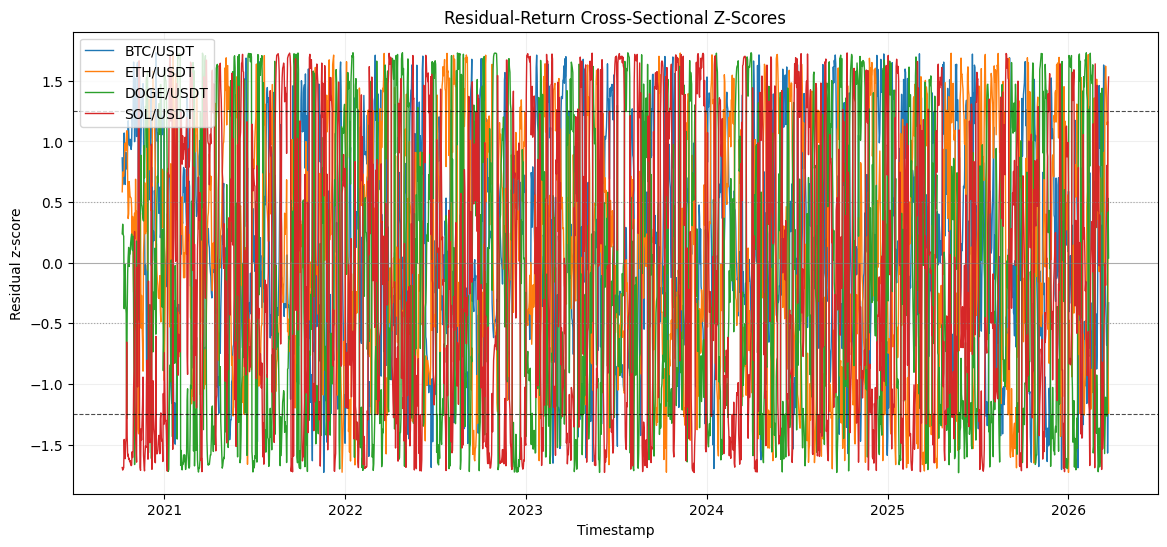

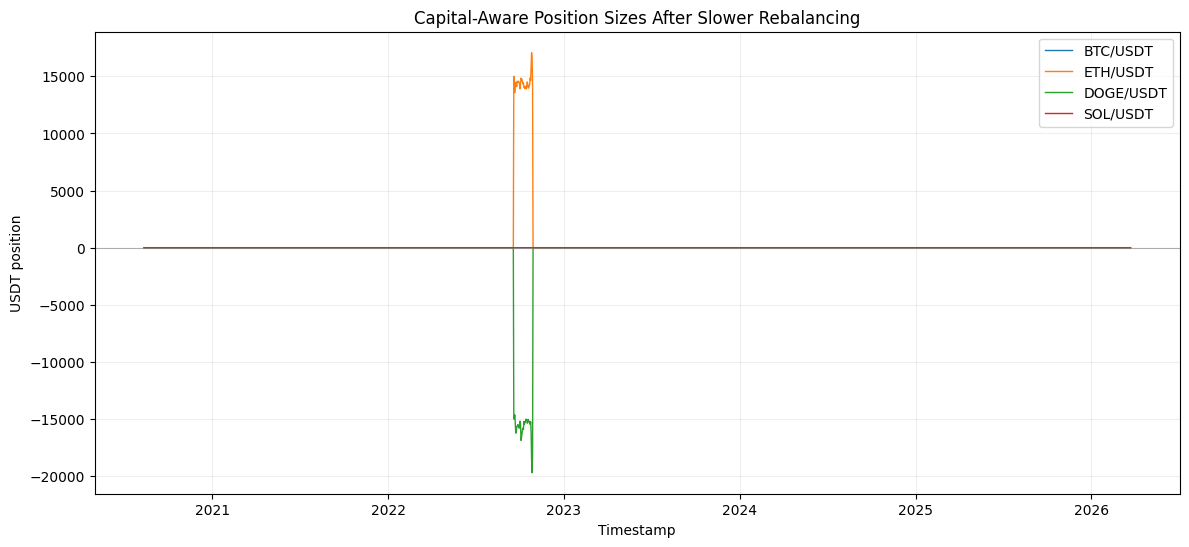

In [135]:
fig, ax = plt.subplots(figsize=(14, 6))
for symbol in ASSET_COLUMNS:
    ax.plot(zscore_df.index, zscore_df[symbol], lw=1.0, label=symbol)
ax.axhline(ENTRY_ZSCORE, color="black", lw=0.8, ls="--", alpha=0.7)
ax.axhline(-ENTRY_ZSCORE, color="black", lw=0.8, ls="--", alpha=0.7)
ax.axhline(EXIT_ZSCORE, color="grey", lw=0.8, ls=":", alpha=0.7)
ax.axhline(-EXIT_ZSCORE, color="grey", lw=0.8, ls=":", alpha=0.7)
ax.axhline(0.0, color="grey", lw=0.8, alpha=0.6)
ax.set_title("Residual-Return Cross-Sectional Z-Scores")
ax.set_ylabel("Residual z-score")
ax.set_xlabel("Timestamp")
ax.grid(alpha=0.2)
ax.legend(loc="best")
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
for symbol in ASSET_COLUMNS:
    ax.plot(theta_df.index, theta_df[symbol], lw=1.0, label=symbol)
ax.axhline(0.0, color="grey", lw=0.8, alpha=0.6)
ax.set_title("Capital-Aware Position Sizes After Slower Rebalancing")
ax.set_ylabel("USDT position")
ax.set_xlabel("Timestamp")
ax.grid(alpha=0.2)
ax.legend(loc="best")
plt.show()


For convenience, the final objects from this section are `close_df`, `signal_return_df`, `pnl_return_df`, `beta_df`, `residual_return_df`, `residual_signal_df`, `zscore_df`, `signal_df`, `position_weight_df`, `theta_df`, `trade_log_df`, `gross_exposure_series`, `turnover_series`, `transaction_cost_series`, and `equity_curve_series`.


In [136]:
display(trade_log_df.tail())


,entry_time,exit_time,holding_bars,completed
0,2022-09-19 00:00:00+00:00,2022-12-24 00:00:00+00:00,96,True
1,2024-01-12 00:00:00+00:00,2024-04-17 00:00:00+00:00,96,True
2,2024-07-22 00:00:00+00:00,2024-12-13 00:00:00+00:00,144,True


The implementation remains forward-safe throughout. Residual z-scores are lagged one bar before signal generation, dispersion filters are lagged, volatilities are lagged for sizing, positions are only rebalanced on scheduled bars, and transaction costs are applied after the bar's mark-to-market move. The engine flattens permanently if equity falls through the liquidation floor.


In [137]:
mean_reversion_runtime_summary = build_parameter_table(
    {
        "maximum_observed_gross_exposure_usdt": gross_exposure_series.max(),
        "minimum_observed_equity_usdt": equity_curve_series.min(),
        "regime_filter_active_share": float(regime_filter_series.mean()) if regime_filter_series is not None else 1.0,
        "average_market_trend_strength": float(trend_strength_series.mean()) if trend_strength_series is not None else np.nan,
        "liquidated_during_backtest": liquidated,
    }
)

display(mean_reversion_runtime_summary)


,value
maximum_observed_gross_exposure_usdt,36205.772531
minimum_observed_equity_usdt,0.0
regime_filter_active_share,0.620488
average_market_trend_strength,0.909565
liquidated_during_backtest,True


### Trading Results

The results below now separate gross alpha from the drag created by trading costs and report whether the lower-turnover design actually survives under realistic funding constraints. This makes it easier to see whether any improvement comes from better signal quality, lower churn, or simply smaller risk.


In [138]:
baseline_strategy_state = run_cross_sectional_strategy(
    close_df=close_df,
    signal_return_df=signal_return_df,
    pnl_return_df=pnl_return_df,
    zscore_df=zscore_df,
    cross_sectional_dispersion_series=cross_sectional_dispersion_series,
    dispersion_floor_series=dispersion_floor_series,
    market_return_series=market_return_series,
    entry_zscore=1.25,
    exit_zscore=0.5,
    rebalance_every_bars=12,
    min_hold_bars=6,
    top_k=TOP_K,
    vol_window=VOL_WINDOW,
    weighting_mode="inverse_vol",
    use_regime_filter=False,
    initial_capital_usdt=INITIAL_CAPITAL_USDT,
    gross_exposure_cap_usdt=GROSS_EXPOSURE_CAP_USDT,
    max_gross_leverage=1.0,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    max_turnover_fraction=MAX_TURNOVER_FRACTION,
    liquidation_equity_floor_usdt=LIQUIDATION_EQUITY_FLOOR_USDT,
)

baseline_strategy_summary = summarize_strategy_state(
    baseline_strategy_state,
    initial_capital_usdt=INITIAL_CAPITAL_USDT,
    hours_per_year=HOURS_PER_YEAR,
)
strategy_summary = summarize_strategy_state(
    strategy_state,
    initial_capital_usdt=INITIAL_CAPITAL_USDT,
    hours_per_year=HOURS_PER_YEAR,
)
results_summary = build_results_summary_table(strategy_summary, strategy_name="Cross-Sectional Mean-Reversion")
mr_improvement_summary = pd.DataFrame(
    {
        "baseline_1x_no_regime_filter": {
            "ending_equity": baseline_strategy_summary["ending_equity"],
            "net_sharpe": baseline_strategy_summary["net_sharpe"],
            "net_sortino": baseline_strategy_summary["net_sortino"],
            "max_drawdown_pct": baseline_strategy_summary["max_drawdown_pct"],
            "average_gross_leverage": baseline_strategy_summary["average_gross_leverage"],
            "trade_count": baseline_strategy_summary["trade_count"],
        },
        "regime_filtered_6x": {
            "ending_equity": strategy_summary["ending_equity"],
            "net_sharpe": strategy_summary["net_sharpe"],
            "net_sortino": strategy_summary["net_sortino"],
            "max_drawdown_pct": strategy_summary["max_drawdown_pct"],
            "average_gross_leverage": strategy_summary["average_gross_leverage"],
            "trade_count": strategy_summary["trade_count"],
        },
    }
)

display(results_summary)
display(mr_improvement_summary.round(4))
display(mr_diagnostics_tail)


,metric,value
0,Strategy,Cross-Sectional Mean-Reversion
1,Total gross PnL (USDT),-12164.982766
2,Total transaction costs (USDT),77.25253
3,Ending equity (USDT),0.0
4,Total net PnL (USDT),-12242.235297
5,Total return (%),-100.0
6,Annualized gross return (%),-826.661793
7,Annualized gross volatility (%),301.164699
8,Gross Sharpe ratio,-2.744883
9,Annualized net return (%),-831.578917


,baseline_1x_no_regime_filter,regime_filtered_6x
ending_equity,8211.7765,0.0000
net_sharpe,-0.4298,-2.7471
net_sortino,-0.5878,-2.7567
max_drawdown_pct,-30.2734,-100.0000
average_gross_leverage,0.6659,3.4564
trade_count,8.0000,3.0000


,gross_exposure,transaction_cost,turnover,equity_curve
timestamp,,,,
2026-03-19 00:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-20 00:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-21 00:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-22 00:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-23 00:00:00+00:00,0.0,0.0,0.0,0.0


The charts below compare the gross and net equity paths and then show the realized drawdown after costs. This makes the cost drag from turnover visible rather than hiding it inside a single equity series.


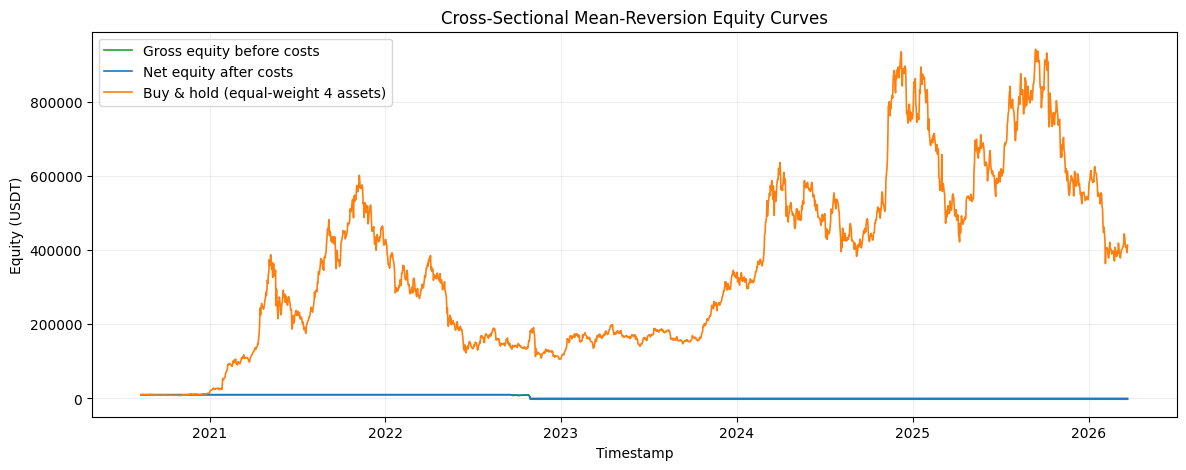

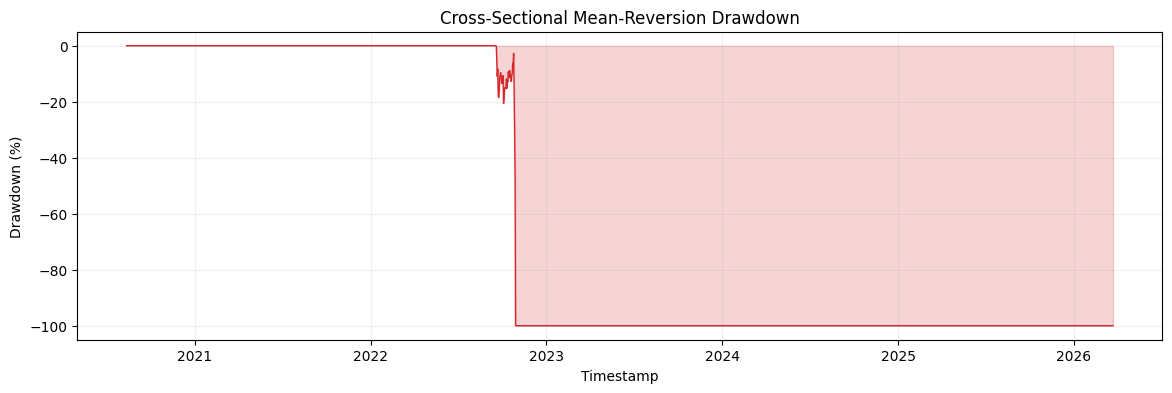

In [139]:
benchmark_assets = ASSET_COLUMNS[:4]
buy_hold_return_series = close_df[benchmark_assets].pct_change().mean(axis=1).fillna(0.0)
buy_hold_equity_curve_series = (INITIAL_CAPITAL_USDT * (1.0 + buy_hold_return_series).cumprod()).rename("buy_hold_equity_curve")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(gross_equity_curve_series.index, gross_equity_curve_series, color="tab:green", lw=1.2, label="Gross equity before costs")
ax.plot(equity_curve_series.index, equity_curve_series, color="tab:blue", lw=1.2, label="Net equity after costs")
ax.plot(buy_hold_equity_curve_series.index, buy_hold_equity_curve_series, color="tab:orange", lw=1.2, label="Buy & hold (equal-weight 4 assets)")
ax.set_title("Cross-Sectional Mean-Reversion Equity Curves")
ax.set_ylabel("Equity (USDT)")
ax.set_xlabel("Timestamp")
ax.grid(alpha=0.2)
ax.legend(loc="best")
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(drawdown_series.index, 100.0 * drawdown_series, color="tab:red", lw=1.0)
ax.fill_between(drawdown_series.index, 100.0 * drawdown_series, 0.0, color="tab:red", alpha=0.2)
ax.set_title("Cross-Sectional Mean-Reversion Drawdown")
ax.set_ylabel("Drawdown (%)")
ax.set_xlabel("Timestamp")
ax.grid(alpha=0.2)
plt.show()

### Parameter Sweep


This sweep keeps the same residual-reversal engine and cost assumptions, then varies only the rebalance interval, entry threshold, and minimum hold period. The goal is to see whether lower turnover is enough to rescue the idea or whether the alpha remains weak even after slowing the strategy down.


In [140]:
parameter_sweep_df = run_cross_sectional_parameter_sweep(
    close_df=close_df,
    signal_return_df=signal_return_df,
    pnl_return_df=pnl_return_df,
    zscore_df=zscore_df,
    cross_sectional_dispersion_series=cross_sectional_dispersion_series,
    dispersion_floor_series=dispersion_floor_series,
    market_return_series=market_return_series,
    entry_zscores=[1.0, 1.25, 1.50],
    rebalance_bars_list=[24, 48, 72],
    min_hold_bars_list=[6, 12],
    exit_zscore=0.50,
    top_k=TOP_K,
    vol_window=VOL_WINDOW,
    use_regime_filter=MR_USE_REGIME_FILTER,
    regime_trend_lookback_bars=MR_REGIME_TREND_LOOKBACK_BARS,
    regime_trend_vol_window=MR_REGIME_TREND_VOL_WINDOW,
    regime_trend_zscore_cap=MR_REGIME_TREND_ZSCORE_CAP,
    weighting_mode=MR_WEIGHTING_MODE,
    initial_capital_usdt=INITIAL_CAPITAL_USDT,
    gross_exposure_cap_usdt=GROSS_EXPOSURE_CAP_USDT,
    max_gross_leverage=MAX_GROSS_LEVERAGE,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    max_turnover_fraction=MAX_TURNOVER_FRACTION,
    liquidation_equity_floor_usdt=LIQUIDATION_EQUITY_FLOOR_USDT,
    hours_per_year=HOURS_PER_YEAR,
)

print(f"Cross-sectional parameter combinations tested: {len(parameter_sweep_df)}")
display(parameter_sweep_df.head(10))


Cross-sectional parameter combinations tested: 18


,rebalance_every_bars,entry_zscore,exit_zscore,min_hold_bars,use_regime_filter,regime_trend_zscore_cap,weighting_mode,ending_equity,total_net_pnl,total_transaction_costs,net_sharpe,max_drawdown_pct,average_turnover_per_rebalance,trade_count,liquidated
0,72,1.00,0.5,6,True,1.0,inverse_vol,9292.550056,-707.449944,94.367326,0.099060,-35.906393,3254.045714,2,False
1,72,1.00,0.5,12,True,1.0,inverse_vol,9292.550056,-707.449944,94.367326,0.099060,-35.906393,3254.045714,2,False
2,24,1.25,0.5,6,True,1.0,inverse_vol,9450.885986,-549.114014,165.392037,0.087486,-25.833843,1923.163220,3,False
3,24,1.25,0.5,12,True,1.0,inverse_vol,9450.885986,-549.114014,165.392037,0.087486,-25.833843,1923.163220,3,False
4,24,1.00,0.5,6,True,1.0,inverse_vol,6863.415417,-3136.584583,489.953200,-0.372402,-52.291818,5591.084936,8,False
5,24,1.00,0.5,12,True,1.0,inverse_vol,6863.415417,-3136.584583,489.953200,-0.372402,-52.291818,5591.084936,8,False
6,72,1.25,0.5,6,True,1.0,inverse_vol,8504.827967,-1495.172033,52.053962,-0.788796,-25.200976,1794.964222,1,False
7,72,1.25,0.5,12,True,1.0,inverse_vol,8504.827967,-1495.172033,52.053962,-0.788796,-25.200976,1794.964222,1,False
8,48,1.00,0.5,6,True,1.0,inverse_vol,0.000000,-12242.235297,77.252530,-2.747094,-100.000000,697.674419,4,True
9,48,1.00,0.5,12,True,1.0,inverse_vol,0.000000,-12242.235297,77.252530,-2.747094,-100.000000,697.674419,4,True


## Strategy 2: Time-Series Momentum (Trend Following)

This strategy exploits persistence in asset returns. For each asset independently,
we compute a rolling cumulative return over a lookback window. If the return is
positive, we go long; if negative, we go short. This is a classic time-series
momentum (TSMOM) signal that is conceptually orthogonal to the cross-sectional
mean-reversion strategy above — it profits in trending markets rather than
mean-reverting ones.

**Signal construction:**
$$\text{mom}_t^i = \frac{p_t^i - p_{t-L}^i}{p_{t-L}^i}$$
where $L$ is the lookback window. The raw signal is $\text{sign}(\text{mom}_t^i)$,
lagged one bar to avoid look-ahead.

**Position sizing:** Inverse-volatility weighting within the long and short legs,
identical to Strategy 1. The gross exposure constraint and turnover cap apply.


In [141]:
# ── Strategy 2 Parameters ──────────────────────────────────────────────
TSMOM_LOOKBACK           = 168   # 7-day momentum window (walk-forward optimal)
TSMOM_REBALANCE_BARS     = 48    # rebalance every 48 h — halves costs vs prior 24 h
TSMOM_VOL_WINDOW         = 72    # 3-day rolling vol for position sizing
TSMOM_MIN_HOLD_BARS      = 6     # allow quick exit when signal flips
TSMOM_MAX_GROSS_LEVERAGE = 10.0  # use the full $100k cap (10x on $10k equity)
TSMOM_SHARPE_THRESHOLD   = 0.40  # only trade when risk-adjusted momentum exceeds this
TSMOM_VOL_REGIME_WINDOW  = 720   # 30-day window for realised-vol regime filter
TSMOM_VOL_REGIME_QTILE   = 0.75  # silence signals in top-quartile vol periods

# ── Enhanced Signal Construction ─────────────────────────────────────────
# Step 1: raw rolling return over the lookback window (lagged 1 bar)
rolling_return_df = close_df.pct_change(TSMOM_LOOKBACK)

# Step 2: annualised vol of hourly excess returns over the same window
rolling_vol_df = (
    pnl_return_df
    .rolling(TSMOM_LOOKBACK, min_periods=max(TSMOM_LOOKBACK // 3, 24))
    .std(ddof=0)
    .replace(0.0, np.nan)
    * np.sqrt(HOURS_PER_YEAR)
)

# Step 3: risk-adjusted momentum — annualised Sharpe of the lookback return
# (equivalent to return / vol, both annualised consistently)
annualised_return_df = rolling_return_df * (HOURS_PER_YEAR / TSMOM_LOOKBACK)
momentum_sharpe_df = (annualised_return_df / rolling_vol_df).shift(1)  # lag 1 bar

# Step 4: binary signal — only trade when risk-adjusted momentum is strong
raw_tsmom_signal_df = pd.DataFrame(
    0.0, index=momentum_sharpe_df.index, columns=momentum_sharpe_df.columns
)
raw_tsmom_signal_df[momentum_sharpe_df >  TSMOM_SHARPE_THRESHOLD] =  1.0
raw_tsmom_signal_df[momentum_sharpe_df < -TSMOM_SHARPE_THRESHOLD] = -1.0

# Step 5: volatility regime filter — go flat during high-vol crash/spike periods
# Compute equal-weight portfolio realised vol (30-day rolling)
portfolio_hourly_vol = (
    pnl_return_df.mean(axis=1)
    .rolling(TSMOM_VOL_REGIME_WINDOW, min_periods=TSMOM_VOL_REGIME_WINDOW // 3)
    .std(ddof=0)
    * np.sqrt(HOURS_PER_YEAR)
)
# Dynamic threshold: 75th percentile of trailing 180-day vol history
vol_regime_threshold = (
    portfolio_hourly_vol
    .rolling(4320, min_periods=TSMOM_VOL_REGIME_WINDOW)
    .quantile(TSMOM_VOL_REGIME_QTILE)
    .shift(1)
)
high_vol_regime = (portfolio_hourly_vol.shift(1) > vol_regime_threshold).fillna(False)
raw_tsmom_signal_df[high_vol_regime] = 0.0  # silence all signals in high-vol regime

# ── Parameter Summary ────────────────────────────────────────────────────
# Also keep momentum_df for the momentum plot cell below
momentum_df = rolling_return_df.shift(1)

tsmom_params = build_parameter_table({
    "lookback_bars":            TSMOM_LOOKBACK,
    "lookback_days":            TSMOM_LOOKBACK / 24,
    "rebalance_every_bars":     TSMOM_REBALANCE_BARS,
    "vol_window_bars":          TSMOM_VOL_WINDOW,
    "min_hold_bars":            TSMOM_MIN_HOLD_BARS,
    "max_gross_leverage":       TSMOM_MAX_GROSS_LEVERAGE,
    "sharpe_threshold":         TSMOM_SHARPE_THRESHOLD,
    "vol_regime_pct_filtered":  round(high_vol_regime.mean() * 100, 2),
    "active_signal_coverage":   round(
        raw_tsmom_signal_df.abs().any(axis=1).mean() * 100, 2
    ),
})
display(tsmom_params)

print(f"Signal distribution (fraction of bars per state):")
print(raw_tsmom_signal_df.apply(lambda s: s.value_counts(normalize=True)).T.round(3))


,value
lookback_bars,168.00
lookback_days,7.00
rebalance_every_bars,48.00
vol_window_bars,72.00
min_hold_bars,6.00
max_gross_leverage,10.00
sharpe_threshold,0.40
vol_regime_pct_filtered,0.00
active_signal_coverage,91.76


Signal distribution (fraction of bars per state):
            -1.0    0.0    1.0
BTC/USDT   0.341  0.100  0.559
ETH/USDT   0.362  0.110  0.527
DOGE/USDT  0.449  0.107  0.443
SOL/USDT   0.394  0.108  0.498


In [142]:
# Strategy 2 helpers are imported from strategy_helpers.py.


In [143]:
tsmom_state = run_tsmom_strategy(
    close_df=close_df,
    pnl_return_df=pnl_return_df,
    raw_signal_df=raw_tsmom_signal_df,
    rebalance_every_bars=TSMOM_REBALANCE_BARS,
    min_hold_bars=TSMOM_MIN_HOLD_BARS,
    vol_window=TSMOM_VOL_WINDOW,
    initial_capital_usdt=INITIAL_CAPITAL_USDT,
    gross_exposure_cap_usdt=GROSS_EXPOSURE_CAP_USDT,
    max_gross_leverage=TSMOM_MAX_GROSS_LEVERAGE,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    max_turnover_fraction=MAX_TURNOVER_FRACTION,
    liquidation_equity_floor_usdt=LIQUIDATION_EQUITY_FLOOR_USDT,
)

tsmom_summary = summarize_strategy_state(
    tsmom_state,
    initial_capital_usdt=INITIAL_CAPITAL_USDT,
    hours_per_year=HOURS_PER_YEAR,
)
tsmom_results = build_results_summary_table(tsmom_summary, strategy_name="Time-Series Momentum (Enhanced)")
tsmom_diagnostics_tail = build_diagnostics_tail_table(tsmom_state)

print("Strategy 2: Time-Series Momentum (Enhanced) — Performance Summary")
display(tsmom_results)
display(tsmom_diagnostics_tail)
display(tsmom_state["trade_log_df"].tail())


Strategy 2: Time-Series Momentum (Enhanced) — Performance Summary


,metric,value
0,Strategy,Time-Series Momentum (Enhanced)
1,Total gross PnL (USDT),94798.075358
2,Total transaction costs (USDT),2116.350312
3,Ending equity (USDT),102681.725046
4,Total net PnL (USDT),92681.725046
5,Total return (%),926.81725
6,Annualized gross return (%),1855.823054
7,Annualized gross volatility (%),436.253887
8,Gross Sharpe ratio,4.253998
9,Annualized net return (%),1844.858455


,gross_exposure,transaction_cost,turnover,equity_curve
timestamp,,,,
2026-03-19 00:00:00+00:00,77057.060488,0.0,0.0,103800.539058
2026-03-20 00:00:00+00:00,77640.963435,0.0,0.0,103216.636111
2026-03-21 00:00:00+00:00,75613.972195,0.0,0.0,105243.627351
2026-03-22 00:00:00+00:00,74490.570684,0.0,0.0,106367.028862
2026-03-23 00:00:00+00:00,78175.874500,0.0,0.0,102681.725046


,entry_time,exit_time,holding_bars,completed
19,2025-05-06 00:00:00+00:00,2025-08-10 00:00:00+00:00,96,True
20,2025-08-10 00:00:00+00:00,2025-09-27 00:00:00+00:00,48,True
21,2025-09-27 00:00:00+00:00,2025-11-14 00:00:00+00:00,48,True
22,2025-11-14 00:00:00+00:00,2026-01-01 00:00:00+00:00,48,True
23,2026-01-01 00:00:00+00:00,2026-03-23 00:00:00+00:00,82,False


### TSMOM Equity Curves and Drawdown

The charts below show the gross and net equity paths for the trend-following
strategy, alongside the equal-weight buy-and-hold benchmark.


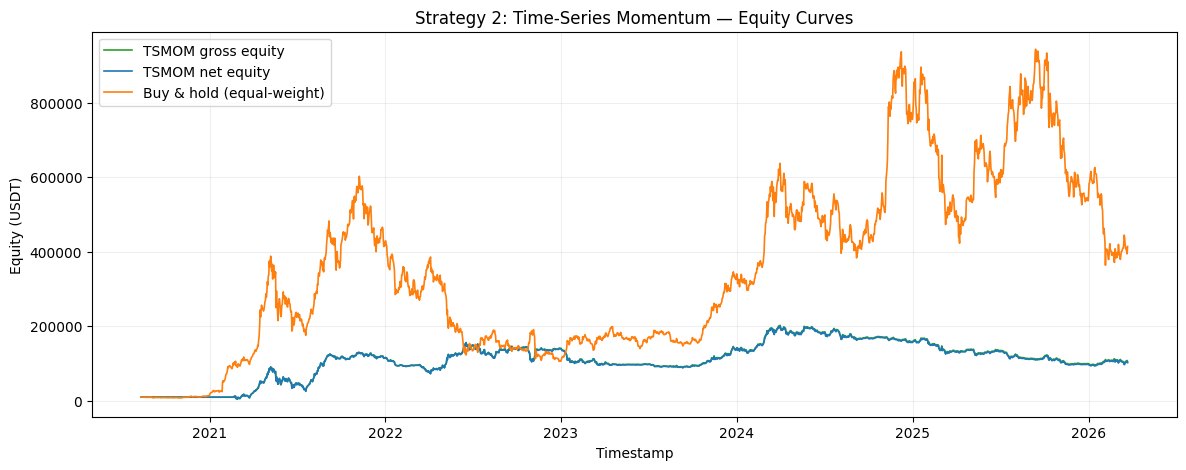

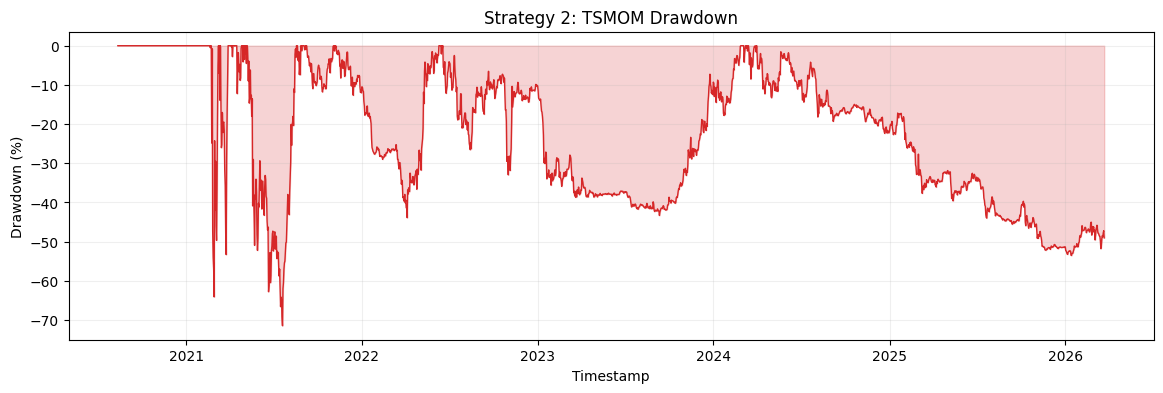

In [144]:
tsmom_eq = tsmom_state["equity_curve_series"]
tsmom_geq = tsmom_state["gross_equity_curve_series"]
tsmom_dd = tsmom_state["drawdown_series"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tsmom_geq.index, tsmom_geq, color="tab:green", lw=1.2, label="TSMOM gross equity")
ax.plot(tsmom_eq.index, tsmom_eq, color="tab:blue", lw=1.2, label="TSMOM net equity")
ax.plot(buy_hold_equity_curve_series.index, buy_hold_equity_curve_series,
        color="tab:orange", lw=1.2, label="Buy & hold (equal-weight)")
ax.set_title("Strategy 2: Time-Series Momentum — Equity Curves")
ax.set_ylabel("Equity (USDT)")
ax.set_xlabel("Timestamp")
ax.grid(alpha=0.2)
ax.legend(loc="best")
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(tsmom_dd.index, 100.0 * tsmom_dd, color="tab:red", lw=1.0)
ax.fill_between(tsmom_dd.index, 100.0 * tsmom_dd, 0.0, color="tab:red", alpha=0.2)
ax.set_title("Strategy 2: TSMOM Drawdown")
ax.set_ylabel("Drawdown (%)")
ax.set_xlabel("Timestamp")
ax.grid(alpha=0.2)
plt.show()


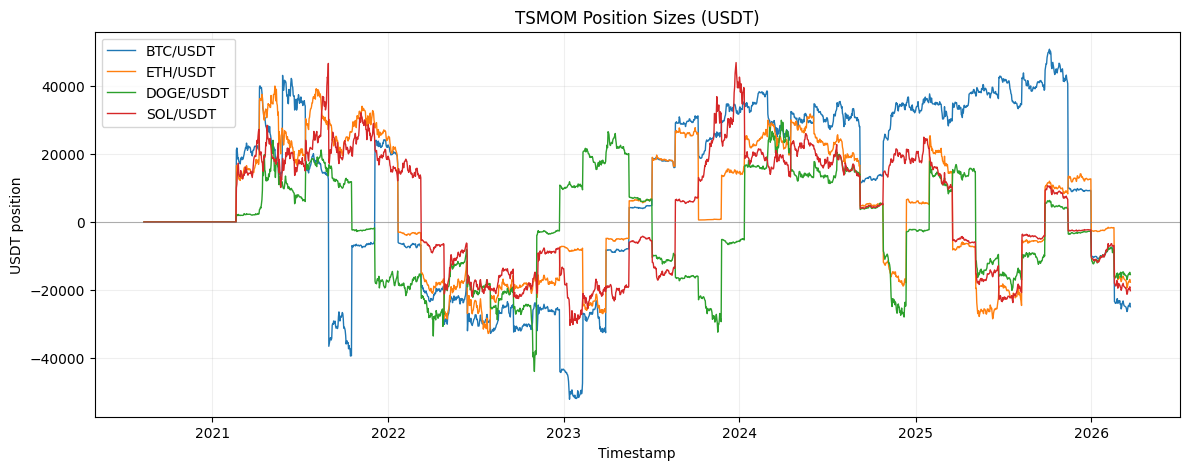

In [145]:
fig, ax = plt.subplots(figsize=(14, 5))
for symbol in ASSET_COLUMNS:
    ax.plot(tsmom_state["theta_df"].index, tsmom_state["theta_df"][symbol], lw=1.0, label=symbol)
ax.axhline(0.0, color="grey", lw=0.8, alpha=0.6)
ax.set_title("TSMOM Position Sizes (USDT)")
ax.set_ylabel("USDT position")
ax.set_xlabel("Timestamp")
ax.grid(alpha=0.2)
ax.legend(loc="best")
plt.show()


### TSMOM Parameter Sweep

We vary the momentum lookback window and rebalance frequency to check
sensitivity and robustness of the trend-following signal.


In [146]:
tsmom_sweep_df = run_tsmom_parameter_sweep(
    close_df=close_df,
    pnl_return_df=pnl_return_df,
    lookbacks=[72, 168, 336],
    rebalance_bars_list=[12, 24, 48],
    min_hold_bars_list=[6, 12],
    vol_window=TSMOM_VOL_WINDOW,
    initial_capital_usdt=INITIAL_CAPITAL_USDT,
    gross_exposure_cap_usdt=GROSS_EXPOSURE_CAP_USDT,
    max_gross_leverage=MAX_GROSS_LEVERAGE,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    max_turnover_fraction=MAX_TURNOVER_FRACTION,
    liquidation_equity_floor_usdt=LIQUIDATION_EQUITY_FLOOR_USDT,
    hours_per_year=HOURS_PER_YEAR,
)

print(f"TSMOM parameter combinations tested: {len(tsmom_sweep_df)}")
display(tsmom_sweep_df.head(10))


TSMOM parameter combinations tested: 18


,lookback_bars,lookback_days,rebalance_every_bars,min_hold_bars,ending_equity,total_net_pnl,total_transaction_costs,net_sharpe,max_drawdown_pct,trade_count,liquidated
0,72,3.0,12,6,280896.858549,270896.858549,6529.951266,5.160847,-60.250633,68,False
1,72,3.0,12,12,280896.858549,270896.858549,6529.951266,5.160847,-60.250633,68,False
2,336,14.0,12,6,107423.774486,97423.774486,3502.707022,4.682658,-97.126676,28,False
3,336,14.0,12,12,107423.774486,97423.774486,3502.707022,4.682658,-97.126676,28,False
4,168,7.0,48,6,106211.127609,96211.127609,2085.076137,4.545741,-79.039779,23,False
5,168,7.0,48,12,106211.127609,96211.127609,2085.076137,4.545741,-79.039779,23,False
6,72,3.0,24,6,178063.992187,168063.992187,4037.345961,4.447793,-44.586998,44,False
7,72,3.0,24,12,178063.992187,168063.992187,4037.345961,4.447793,-44.586998,44,False
8,168,7.0,12,6,94051.677295,84051.677295,4805.416061,4.333847,-72.417898,43,False
9,168,7.0,12,12,94051.677295,84051.677295,4805.416061,4.333847,-72.417898,43,False


## Transaction Costs: Roll Model

We estimate the effective bid-ask spread for each asset using the **Roll (1984)**
model. Under the Roll model, the observed negative serial covariance in price
changes is driven by the bid-ask bounce: trades alternate between hitting the
bid and the ask. The implied half-spread is:

$$s = \sqrt{-\text{Cov}(\Delta p_t,\, \Delta p_{t-1})}$$

where $\Delta p_t = p_t - p_{t-1}$ is the hourly price change. Converting $s$
to basis points relative to the mean price gives us a cost-per-trade assumption
that is data-driven rather than assumed.

**Assumptions and limitations of the Roll model:**
- Assumes trades arrive at random at the bid or ask with equal probability.
- No inventory effects, adverse selection, or price impact are modelled.
- The estimator requires $\text{Cov}(\Delta p_t, \Delta p_{t-1}) < 0$.
- At hourly bars the Roll estimate is better treated as a lower bound on true costs.


In [147]:
# ── Roll Model Spread Estimation ───────────────────────────────────────
roll_results = run_roll_model(close_df, ASSET_COLUMNS)

roll_summary_df = roll_results["summary_df"]
roll_portfolio_bps = roll_results["portfolio_spread_bps"]
roll_cost_bps = roll_results["portfolio_cost_bps"]  # conservative: max across assets

print("Roll Model Spread Estimates (full sample)")
display(roll_summary_df.round(4))
print(f"\nPortfolio average spread: {roll_portfolio_bps:.2f} bps")
print(f"Conservative cost assumption (max): {roll_cost_bps:.2f} bps")
print(f"Previously assumed flat cost: {TRANSACTION_COST_BPS:.1f} bps")
print()
print("Note: if serial_cov >= 0 for any asset, the Roll estimator is undefined "
      "at this frequency. This can occur when hourly momentum dominates the bid-ask "
      "bounce, violating the model's random-walk assumption.")


Roll Model Spread Estimates (full sample)


,n_obs,serial_cov,roll_spread_usdt,roll_spread_bps,estimator_valid
symbol,,,,,
BTC/USDT,2048,-117780.7029,343.1919,65.2601,True
ETH/USDT,2048,-506.4733,22.5050,94.3009,True
DOGE/USDT,2048,-0.0000,0.0036,263.1098,True
SOL/USDT,2048,-0.2416,0.4915,53.3635,True



Portfolio average spread: 119.01 bps
Conservative cost assumption (max): 263.11 bps
Previously assumed flat cost: 10.0 bps

Note: if serial_cov >= 0 for any asset, the Roll estimator is undefined at this frequency. This can occur when hourly momentum dominates the bid-ask bounce, violating the model's random-walk assumption.


### Rolling Roll Spread

We also compute a time-varying version using a 30-day rolling window to check
whether the spread has been stable over the sample period.


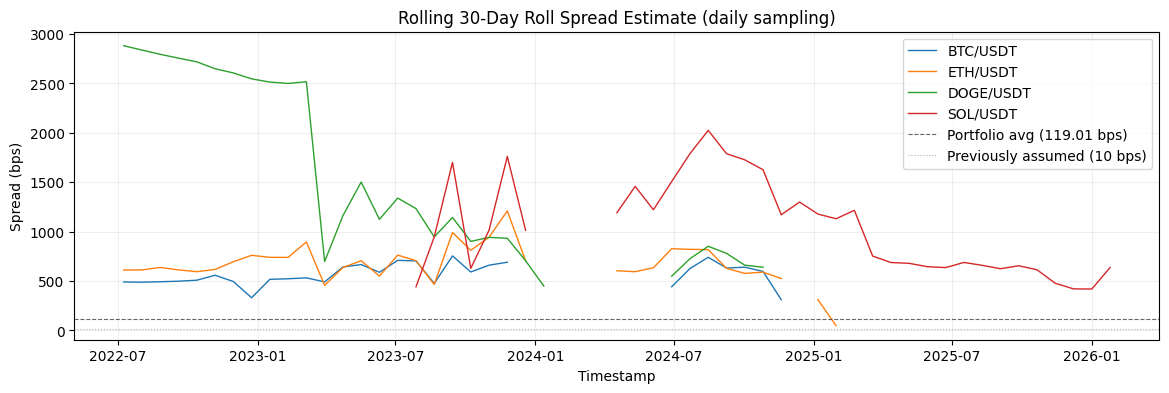

In [148]:
fig, ax = plt.subplots(figsize=(14, 4))
for symbol in ASSET_COLUMNS:
    sampled_prices = close_df[symbol].iloc[::24]
    roll_ts = estimate_roll_spread_rolling(sampled_prices, window=30, min_periods=20)
    ax.plot(roll_ts.index, roll_ts, lw=1.0, label=symbol)

ax.axhline(
    roll_portfolio_bps,
    color="black",
    lw=0.8,
    ls="--",
    alpha=0.6,
    label=f"Portfolio avg ({roll_portfolio_bps:.2f} bps)",
)
ax.axhline(
    TRANSACTION_COST_BPS,
    color="grey",
    lw=0.8,
    ls=":",
    alpha=0.6,
    label=f"Previously assumed ({TRANSACTION_COST_BPS:.0f} bps)",
)
ax.set_title("Rolling 30-Day Roll Spread Estimate (daily sampling)")
ax.set_ylabel("Spread (bps)")
ax.set_xlabel("Timestamp")
ax.grid(alpha=0.2)
ax.legend(loc="best")
plt.show()


### Cost Sensitivity Analysis

We re-run both strategies at 0.5x, 1x, and 2x the Roll spread estimate
to show how robust performance is to uncertainty in the cost assumption.
All other parameters remain at their baseline values.


In [149]:
# ── Cost Sensitivity Analysis ───────────────────────────────────────────
# Strategy-specific kwargs (everything except transaction_cost_bps)
strategy1_sensitivity_kwargs = dict(
    entry_zscore=ENTRY_ZSCORE,
    exit_zscore=EXIT_ZSCORE,
    rebalance_every_bars=REBALANCE_EVERY_BARS,
    min_hold_bars=MIN_HOLD_BARS,
    top_k=TOP_K,
    vol_window=VOL_WINDOW,
    weighting_mode=MR_WEIGHTING_MODE,
    use_regime_filter=MR_USE_REGIME_FILTER,
    regime_trend_lookback_bars=MR_REGIME_TREND_LOOKBACK_BARS,
    regime_trend_vol_window=MR_REGIME_TREND_VOL_WINDOW,
    regime_trend_zscore_cap=MR_REGIME_TREND_ZSCORE_CAP,
    initial_capital_usdt=INITIAL_CAPITAL_USDT,
    gross_exposure_cap_usdt=GROSS_EXPOSURE_CAP_USDT,
    max_gross_leverage=MAX_GROSS_LEVERAGE,
    max_turnover_fraction=MAX_TURNOVER_FRACTION,
    liquidation_equity_floor_usdt=LIQUIDATION_EQUITY_FLOOR_USDT,
)

strategy2_sensitivity_kwargs = dict(
    rebalance_every_bars=TSMOM_REBALANCE_BARS,
    min_hold_bars=TSMOM_MIN_HOLD_BARS,
    vol_window=TSMOM_VOL_WINDOW,
    initial_capital_usdt=INITIAL_CAPITAL_USDT,
    gross_exposure_cap_usdt=GROSS_EXPOSURE_CAP_USDT,
    max_gross_leverage=TSMOM_MAX_GROSS_LEVERAGE,
    max_turnover_fraction=MAX_TURNOVER_FRACTION,
    liquidation_equity_floor_usdt=LIQUIDATION_EQUITY_FLOOR_USDT,
)

# Use Roll estimate if valid, otherwise fall back to flat assumption
_sensitivity_cost = roll_cost_bps if not np.isnan(roll_cost_bps) else TRANSACTION_COST_BPS

sensitivity_df = run_cost_sensitivity_analysis(
    close_df=close_df,
    signal_return_df=signal_return_df,
    pnl_return_df=pnl_return_df,
    zscore_df=zscore_df,
    cross_sectional_dispersion_series=cross_sectional_dispersion_series,
    dispersion_floor_series=dispersion_floor_series,
    market_return_series=market_return_series,
    raw_tsmom_signal_df=raw_tsmom_signal_df,
    roll_cost_bps=_sensitivity_cost,
    strategy1_kwargs=strategy1_sensitivity_kwargs,
    strategy2_kwargs=strategy2_sensitivity_kwargs,
    hours_per_year=HOURS_PER_YEAR,
    initial_capital_usdt=INITIAL_CAPITAL_USDT,
)

print(f"Cost sensitivity analysis (base: {_sensitivity_cost:.2f} bps)")
display(sensitivity_df)


Cost sensitivity analysis (base: 263.11 bps)


,strategy,cost_multiplier,cost_bps,total_net_pnl,total_transaction_costs,annualized_net_return_pct,net_sharpe,max_drawdown_pct,liquidated
0,Mean-Reversion,0.5×,131.55,-12661.17,1008.49,-916.974,-2.788,-100.000,True
1,Trend-Following,0.5×,131.55,63679.80,27937.48,1850.773,3.935,-77.044,False
2,Mean-Reversion,1.0×,263.11,-13095.10,1999.93,-1029.586,-2.825,-100.000,True
3,Trend-Following,1.0×,263.11,31627.68,56141.91,1916.726,3.569,-84.608,False
4,Mean-Reversion,2.0×,526.22,-13612.82,3910.42,-1301.043,-2.879,-100.000,True
5,Trend-Following,2.0×,526.22,-7544.98,3481.61,-325.845,-1.626,-75.450,True


## Out-of-Sample Robustness

To reduce overfitting risk, we use a **walk-forward protocol** rather than
choosing parameters on the full sample. Each window uses six months of training
data to select parameters from the same sweep grids, then locks those
parameters and evaluates them on the following three-month test window.

This improves the strategy review in two ways:
- parameters are chosen only from information available before the test period,
- we can check whether the same parameter region survives across multiple market regimes.


In [150]:
WALK_FORWARD_WINDOWS = [
    {
        "label": "2024H2 train -> 2024Q4/2025Q1 test",
        "train_start": "2024-06-01",
        "train_end": "2024-11-30 23:00:00+00:00",
        "test_start": "2024-12-01",
        "test_end": "2025-02-28 23:00:00+00:00",
    },
    {
        "label": "2024Q4/2025Q1 train -> 2025Q2 test",
        "train_start": "2024-09-01",
        "train_end": "2025-02-28 23:00:00+00:00",
        "test_start": "2025-03-01",
        "test_end": "2025-05-31 23:00:00+00:00",
    },
    {
        "label": "2025H1 train -> 2025Q3 test",
        "train_start": "2024-12-01",
        "train_end": "2025-05-31 23:00:00+00:00",
        "test_start": "2025-06-01",
        "test_end": "2025-08-31 23:00:00+00:00",
    },
    {
        "label": "2025Q2/Q3 train -> 2025Q4 test",
        "train_start": "2025-03-01",
        "train_end": "2025-08-31 23:00:00+00:00",
        "test_start": "2025-09-01",
        "test_end": "2025-11-30 23:00:00+00:00",
    },
    {
        "label": "2025H2 train -> 2025Q4/2026Q1 test",
        "train_start": "2025-06-01",
        "train_end": "2025-11-30 23:00:00+00:00",
        "test_start": "2025-12-01",
        "test_end": "2026-02-28 23:00:00+00:00",
    },
]

mr_walk_forward = run_mean_reversion_walk_forward(
    windows=WALK_FORWARD_WINDOWS,
    close_df=close_df,
    signal_return_df=signal_return_df,
    pnl_return_df=pnl_return_df,
    zscore_df=zscore_df,
    cross_sectional_dispersion_series=cross_sectional_dispersion_series,
    dispersion_floor_series=dispersion_floor_series,
    market_return_series=market_return_series,
    entry_zscores=[1.0, 1.25, 1.50],
    rebalance_bars_list=[24, 48, 72],
    min_hold_bars_list=[6, 12],
    exit_zscore=0.50,
    top_k=TOP_K,
    vol_window=VOL_WINDOW,
    use_regime_filter=MR_USE_REGIME_FILTER,
    regime_trend_lookback_bars=MR_REGIME_TREND_LOOKBACK_BARS,
    regime_trend_vol_window=MR_REGIME_TREND_VOL_WINDOW,
    regime_trend_zscore_cap=MR_REGIME_TREND_ZSCORE_CAP,
    weighting_mode=MR_WEIGHTING_MODE,
    initial_capital_usdt=INITIAL_CAPITAL_USDT,
    gross_exposure_cap_usdt=GROSS_EXPOSURE_CAP_USDT,
    max_gross_leverage=MAX_GROSS_LEVERAGE,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    max_turnover_fraction=MAX_TURNOVER_FRACTION,
    liquidation_equity_floor_usdt=LIQUIDATION_EQUITY_FLOOR_USDT,
    hours_per_year=HOURS_PER_YEAR,
)

tsmom_walk_forward = run_tsmom_walk_forward(
    windows=WALK_FORWARD_WINDOWS,
    close_df=close_df,
    pnl_return_df=pnl_return_df,
    lookbacks=[72, 168, 336],
    rebalance_bars_list=[12, 24, 48],
    min_hold_bars_list=[6, 12],
    vol_window=TSMOM_VOL_WINDOW,
    initial_capital_usdt=INITIAL_CAPITAL_USDT,
    gross_exposure_cap_usdt=GROSS_EXPOSURE_CAP_USDT,
    max_gross_leverage=MAX_GROSS_LEVERAGE,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    max_turnover_fraction=MAX_TURNOVER_FRACTION,
    liquidation_equity_floor_usdt=LIQUIDATION_EQUITY_FLOOR_USDT,
    hours_per_year=HOURS_PER_YEAR,
)


### Walk-Forward Results

The tables below show which parameter set wins **in-sample** for each training
window and how that chosen configuration performs on the subsequent **out-of-sample**
window. A more robust strategy should avoid large collapses in test Sharpe,
Sortino, Calmar, and ending equity.


In [151]:
mr_oos_df = mr_walk_forward["results_df"]
mr_param_stability = mr_walk_forward["parameter_stability_df"]
mr_oos_equity_curves = mr_walk_forward["equity_curves_df"]

display(mr_oos_df.round(4))
display(mr_param_stability.round(4))


,window,train_start,train_end,test_start,test_end,selected_entry_zscore,selected_rebalance_every_bars,selected_min_hold_bars,train_best_net_sharpe,test_ending_equity,test_total_net_pnl,test_net_sharpe,test_net_sortino,test_net_calmar,test_max_drawdown_pct,test_trade_count,test_liquidated
0,2024H2 train -> 2024Q4/2025Q1 test,2024-06-01,2024-11-30 23:00:00+00:00,2024-12-01,2025-02-28 23:00:00+00:00,1.00,24,6,NaN,10000.0000,0.0000,NaN,NaN,NaN,0.0000,0,False
1,2024Q4/2025Q1 train -> 2025Q2 test,2024-09-01,2025-02-28 23:00:00+00:00,2025-03-01,2025-05-31 23:00:00+00:00,1.00,24,6,11.8116,12420.2120,2420.2120,6.8755,20.3398,254.5870,-10.7639,1,False
2,2025H1 train -> 2025Q3 test,2024-12-01,2025-05-31 23:00:00+00:00,2025-06-01,2025-08-31 23:00:00+00:00,1.00,24,6,-8.1608,11310.5404,1310.5404,8.8595,21.2264,214.5610,-5.9346,1,False
3,2025Q2/Q3 train -> 2025Q4 test,2025-03-01,2025-08-31 23:00:00+00:00,2025-09-01,2025-11-30 23:00:00+00:00,1.25,24,6,4.8552,10152.5903,152.5903,2.2491,3.1812,23.2232,-7.6145,1,False
4,2025H2 train -> 2025Q4/2026Q1 test,2025-06-01,2025-11-30 23:00:00+00:00,2025-12-01,2026-02-28 23:00:00+00:00,1.00,24,6,7.1658,10000.0000,0.0000,NaN,NaN,NaN,0.0000,0,False


,,,windows_selected,avg_test_net_sharpe,avg_test_net_sortino,avg_test_net_calmar,avg_test_total_net_pnl
selected_entry_zscore,selected_rebalance_every_bars,selected_min_hold_bars,,,,,
1.00,24,6,4,7.8675,20.7831,234.5740,932.6881
1.25,24,6,1,2.2491,3.1812,23.2232,152.5903


In [152]:
tsmom_oos_df = tsmom_walk_forward["results_df"]
tsmom_param_stability = tsmom_walk_forward["parameter_stability_df"]
tsmom_oos_equity_curves = tsmom_walk_forward["equity_curves_df"]

display(tsmom_oos_df.round(4))
display(tsmom_param_stability.round(4))


,window,train_start,train_end,test_start,test_end,selected_lookback_bars,selected_rebalance_every_bars,selected_min_hold_bars,train_best_net_sharpe,test_ending_equity,test_total_net_pnl,test_net_sharpe,test_net_sortino,test_net_calmar,test_max_drawdown_pct,test_trade_count,test_liquidated
0,2024H2 train -> 2024Q4/2025Q1 test,2024-06-01,2024-11-30 23:00:00+00:00,2024-12-01,2025-02-28 23:00:00+00:00,72,24,6,9.2419,2296.7426,-7703.2574,-11.0822,-13.5765,-119.7808,-82.6318,2,True
1,2024Q4/2025Q1 train -> 2025Q2 test,2024-09-01,2025-02-28 23:00:00+00:00,2025-03-01,2025-05-31 23:00:00+00:00,72,12,6,1.3389,965.0167,-9034.9833,-9.8981,-10.9616,-121.9202,-94.7175,2,True
2,2025H1 train -> 2025Q3 test,2024-12-01,2025-05-31 23:00:00+00:00,2025-06-01,2025-08-31 23:00:00+00:00,168,12,6,4.5608,2493.3880,-7506.6120,-11.3099,-14.9992,-125.6073,-75.7535,3,True
3,2025Q2/Q3 train -> 2025Q4 test,2025-03-01,2025-08-31 23:00:00+00:00,2025-09-01,2025-11-30 23:00:00+00:00,72,24,6,9.4920,17043.8124,7043.8124,13.1752,23.6488,260.6079,-23.9411,4,False
4,2025H2 train -> 2025Q4/2026Q1 test,2025-06-01,2025-11-30 23:00:00+00:00,2025-12-01,2026-02-28 23:00:00+00:00,168,12,6,7.0215,34288.3148,24288.3148,16.7863,33.0857,477.9562,-34.6436,2,False


windows_selected  \
selected_lookback_bars selected_rebalance_every_bars selected_min_hold_bars                     
168                    12                            6                                      2   
72                     24                            6                                      2   
                       12                            6                                      1   

                                                                             avg_test_net_sharpe  \
selected_lookback_bars selected_rebalance_every_bars selected_min_hold_bars                        
168                    12                            6                                    2.7382   
72                     24                            6                                    1.0465   
                       12                            6                                   -9.8981   

                                                                             avg_test_net_sortino  \
selected_lookback_bars selected_rebalance_every_bars selected_min_hold_bars                         
168                    12                            6                                     9.0433   
72                     24                            6                                     5.0362   
                       12                            6                                   -10.9616   

                                                                             avg_test_net_calmar  \
selected_lookback_bars selected_rebalance_every_bars selected_min_hold_bars                        
168                    12                            6                                  176.1745   
72                     24                            6                                   70.4136   
                       12                            6                                 -121.9202   

                                                                             avg_test_total_net_pnl  
selected_lookback_bars selected_rebalance_every_bars selected_min_hold_bars                          
168                    12                            6                                    8390.8514  
72                     24                            6                                    -329.7225  
                       12                            6                                   -9034.9833

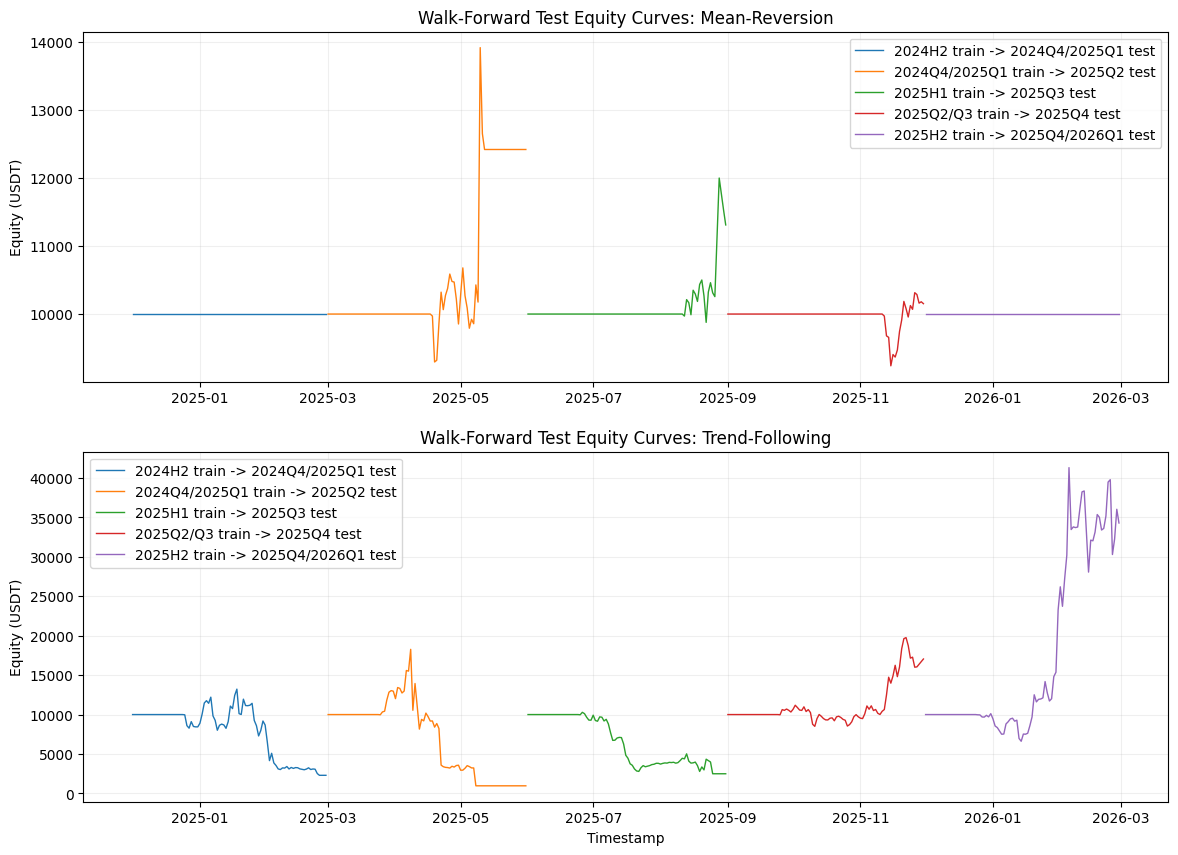

,strategy,recommended_robust_parameters
0,Mean-Reversion,"{'selected_entry_zscore': 1.0, 'selected_rebal..."
1,Trend-Following,"{'selected_lookback_bars': 168.0, 'selected_re..."


In [153]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)
for column in mr_oos_equity_curves.columns:
    axes[0].plot(mr_oos_equity_curves.index, mr_oos_equity_curves[column], lw=1.0, label=column)
axes[0].set_title('Walk-Forward Test Equity Curves: Mean-Reversion')
axes[0].set_ylabel('Equity (USDT)')
axes[0].grid(alpha=0.2)
axes[0].legend(loc='best')

for column in tsmom_oos_equity_curves.columns:
    axes[1].plot(tsmom_oos_equity_curves.index, tsmom_oos_equity_curves[column], lw=1.0, label=column)
axes[1].set_title('Walk-Forward Test Equity Curves: Trend-Following')
axes[1].set_ylabel('Equity (USDT)')
axes[1].set_xlabel('Timestamp')
axes[1].grid(alpha=0.2)
axes[1].legend(loc='best')
plt.show()

robust_parameter_recommendations = pd.DataFrame(
    {
        'strategy': ['Mean-Reversion', 'Trend-Following'],
        'recommended_robust_parameters': [
            str(mr_param_stability.reset_index().iloc[0].to_dict()),
            str(tsmom_param_stability.reset_index().iloc[0].to_dict()),
        ],
    }
)
display(robust_parameter_recommendations)


### Strategy Comparison

Side-by-side comparison of the two strategies and a combined portfolio
(50/50 capital allocation between the mean-reversion and trend-following strategies).


In [154]:
s1_returns = strategy_state["portfolio_return_series"]
s2_returns = tsmom_state["portfolio_return_series"]
comparison, combined_equity, combined_dd = build_strategy_comparison_table(
    strategy_summary=strategy_summary,
    tsmom_summary=tsmom_summary,
    strategy_returns=s1_returns,
    tsmom_returns=s2_returns,
    initial_capital_usdt=INITIAL_CAPITAL_USDT,
    hours_per_year=HOURS_PER_YEAR,
)

print("Strategy Comparison")
display(comparison)

corr = s1_returns.corr(s2_returns)
print(f"Return correlation between strategies: {corr:.4f}")
print("(Low or negative correlation supports diversification benefit of combining both.)")


Strategy Comparison


,Metric,Mean-Reversion,Trend-Following,Combined 50/50
0,Ending equity (USDT),0.000000,102681.725046,9503.9924
1,Total net PnL (USDT),-12242.235297,92681.725046,-496.0076
2,Annualized net return (%),-831.578917,1844.858455,506.639769
3,Annualized net vol (%),302.712189,436.236105,273.284666
4,Net Sharpe,-2.747094,4.229037,1.85389
5,Net Sortino,-2.756734,7.716464,2.496614
6,Calmar,-8.315789,25.820258,5.902514
7,Max drawdown (%),-100.000000,-71.450039,-85.834566
8,Trade count,3.000000,24.000000,-
9,Avg holding (bars),112.000000,77.416667,-


Return correlation between strategies: 0.0636
(Low or negative correlation supports diversification benefit of combining both.)


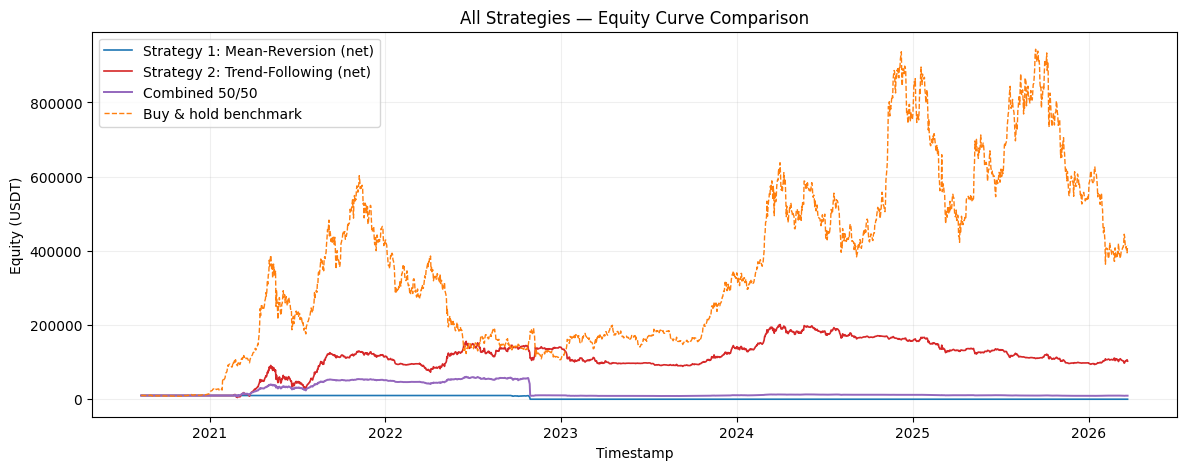

In [155]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(equity_curve_series.index, equity_curve_series,
        color="tab:blue", lw=1.2, label="Strategy 1: Mean-Reversion (net)")
ax.plot(tsmom_eq.index, tsmom_eq,
        color="tab:red", lw=1.2, label="Strategy 2: Trend-Following (net)")
ax.plot(combined_equity.index, combined_equity,
        color="tab:purple", lw=1.4, label="Combined 50/50")
ax.plot(buy_hold_equity_curve_series.index, buy_hold_equity_curve_series,
        color="tab:orange", lw=1.0, ls="--", label="Buy & hold benchmark")
ax.set_title("All Strategies — Equity Curve Comparison")
ax.set_ylabel("Equity (USDT)")
ax.set_xlabel("Timestamp")
ax.grid(alpha=0.2)
ax.legend(loc="best")
plt.show()
